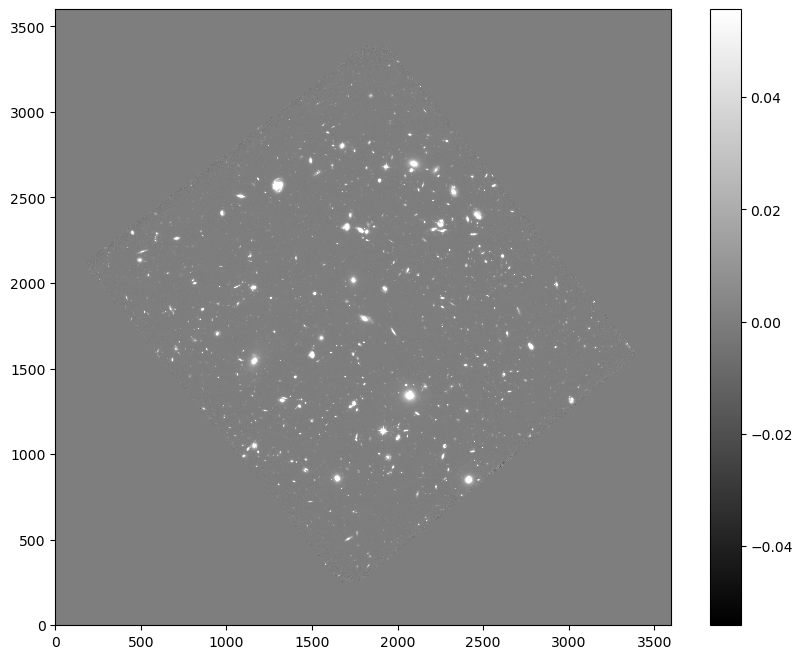

In [1]:
import numpy as np
import sep
import astropy
import matplotlib.pyplot as plt
from matplotlib import rcParams
%matplotlib inline
rcParams['figure.figsize']=[10.,8.]
from astropy.io import fits
with fits.open("text.fits") as hdul:
    data = hdul[0].data
# showing the image
m, s = np.mean(data), np.std(data)
plt.imshow(data, interpolation='nearest', cmap='gray', vmin=m-s, vmax=m+s, origin='lower')
plt.colorbar();
plt.savefig('image_fits.png',bbox_inches='tight',dpi=1000)

In [2]:
data=data.astype(data.dtype.newbyteorder('='))
bkg =sep.Background(data)

In [3]:
print(bkg.globalback)
print(bkg.globalrms)

0.0
0.0005398219218477607


In [4]:
bkg_image = bkg.back()

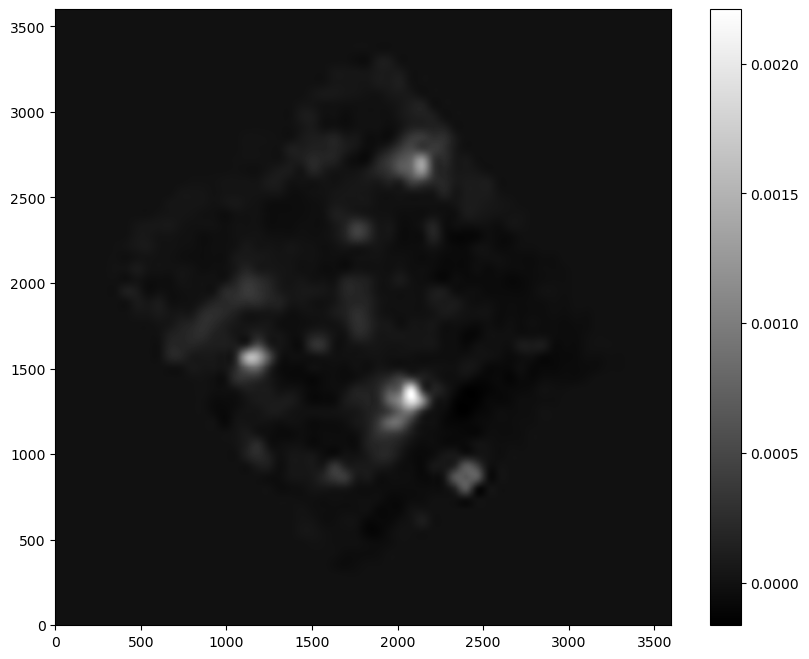

In [5]:
# showing the background
plt.imshow(bkg_image, interpolation='nearest', cmap='gray', origin='lower')
plt.colorbar();

In [6]:
bkg_rms = bkg.rms()

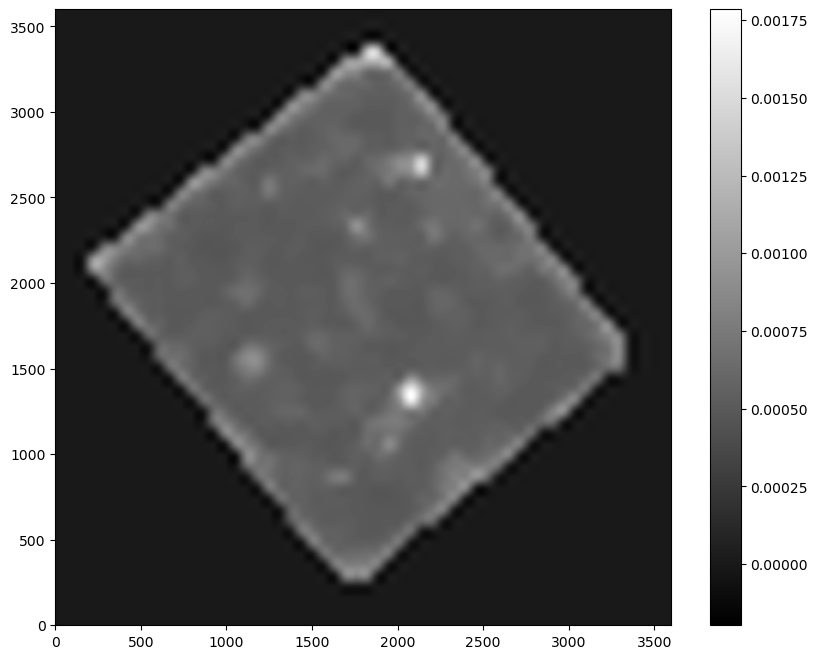

In [7]:
# showing the background noise
plt.imshow(bkg_rms, interpolation='nearest', cmap='gray', origin='lower')
plt.colorbar();

In [8]:
data_sub = data - bkg

In [9]:
objects = sep.extract(data_sub,1000, err=bkg.globalrms)

In [10]:
len(objects)

20

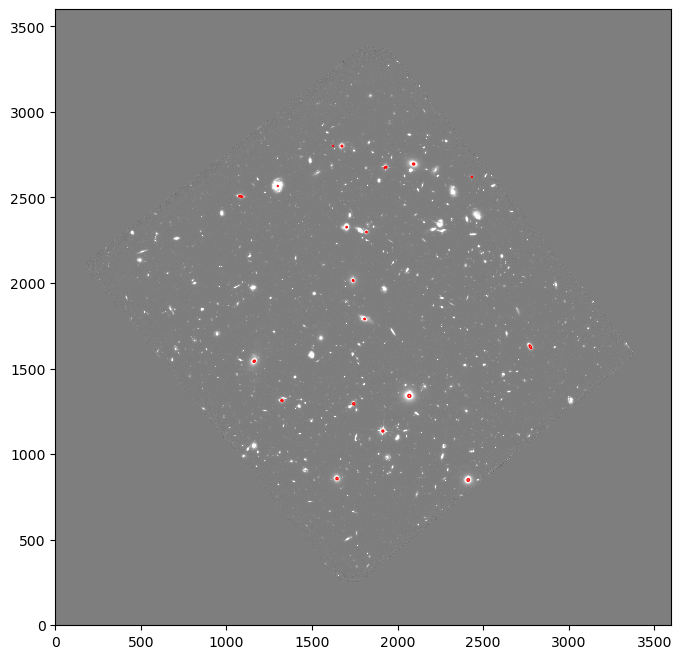

In [11]:
from matplotlib.patches import Ellipse
# woohooo starting to plot now
fig, ax = plt.subplots()
m, s = np.mean(data_sub), np.std(data_sub)
im = ax.imshow(data_sub, interpolation='nearest', cmap='gray',
               vmin=m-s, vmax=m+s, origin='lower')
#ellipse and starting to find the objects in our image
for i in range(len(objects)):
    e = Ellipse(xy=(objects['x'][i], objects['y'][i]),
    width=6*objects['a'][i],
    height=6*objects['b'][i],
    angle=objects['theta'] [i] * 180. / np.pi)
    e.set_facecolor('none')
    e.set_edgecolor('red')
    ax.add_artist(e)

In [12]:
flux, fluxerr, flag = sep.sum_circle(data_sub, objects['x'], objects['y'],
                                     3.0, err=bkg.globalrms, gain=1.0)

In [13]:
# showing the objects flux results:
for i in range(len(objects)):
    print("object {:d}: flux = {:f} +/- {:f}".format(i, flux[i], fluxerr[i]))

object 0: flux = 65.798342 +/- 8.111618
object 1: flux = 72.364693 +/- 8.506744
object 2: flux = 806.772766 +/- 28.403746
object 3: flux = 51.973451 +/- 7.209262
object 4: flux = 45.524070 +/- 6.747153
object 5: flux = 77.932309 +/- 8.827928
object 6: flux = 56.780905 +/- 7.535311
object 7: flux = 24.511623 +/- 4.950922
object 8: flux = 22.083595 +/- 4.699319
object 9: flux = 35.945310 +/- 5.995441
object 10: flux = 27.027819 +/- 5.198829
object 11: flux = 18.385864 +/- 4.287875
object 12: flux = 34.948310 +/- 5.911710
object 13: flux = 15.025255 +/- 3.876244
object 14: flux = 30.047611 +/- 5.481571
object 15: flux = 26.542590 +/- 5.151951
object 16: flux = 214.216629 +/- 14.636141
object 17: flux = 43.866376 +/- 6.623170
object 18: flux = 17.081854 +/- 4.133021
object 19: flux = 81.654579 +/- 9.036293


Text(0.5, 1.0, 'Histogram of Fluxes')

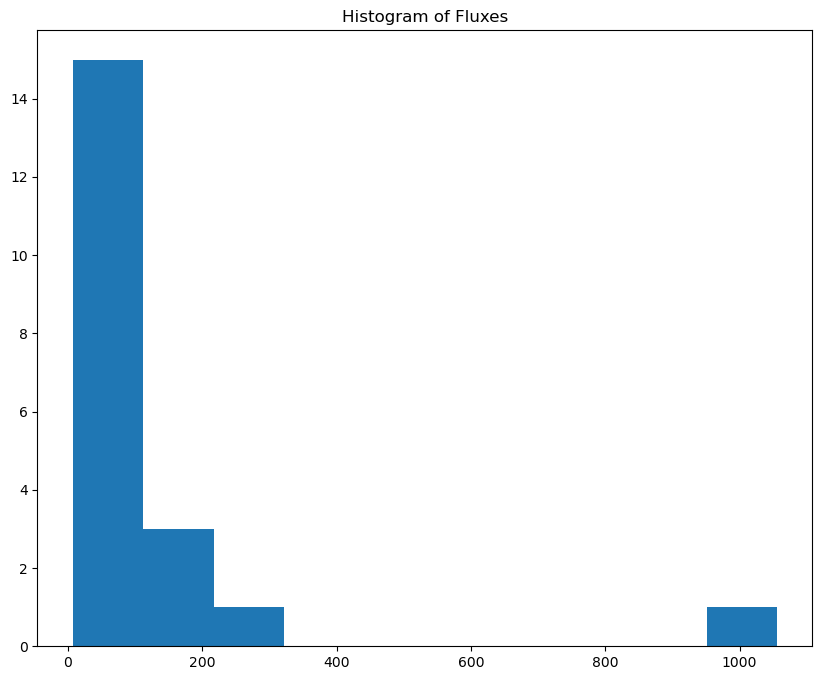

In [14]:
a = np.histogram(objects['flux'], bins=10,range=None, weights=None, density=None)
plt.hist(objects['flux'], bins=10)
plt.title("Histogram of Fluxes")

In [15]:
m, s ,md= np.mean(objects['flux']), np.std(objects['flux']),np.median(objects['flux'])
print("Mean: ",m)
print("Standard Deviation: ",s)
print("Median: ",md)

Mean:  126.30622134208679
Standard Deviation:  222.3228803026822
Median:  70.77364730834961


now that we have the mean and median we can start on the distance from max and min values from the average in next plot (mean =126 and median is 70)

In [16]:
mx= (np.max(objects['flux']))
mn = (np.min (objects['flux']))

dist1=mx-m
dist2 =m-mn
print("Distance of max value from mean: ",dist1, "\nDistance of min value from mean:",dist2)
print("Largest Outlier: ",mx)

Distance of max value from mean:  929.8876263141632 
Distance of min value from mean: 119.15347228050231
Largest Outlier:  1056.19384765625


Dist1 > than Dist2 (929 vs 119) with largest outlier being 1056.19384765625 so now we use that to find the largest outlier in standard deviations

In [17]:
final = dist1/md
print("Largest Outlier's distance from the mean in terms of Standard Deviations: ",final)
result = np.where(objects['flux'] == mx)
print(result)

Largest Outlier's distance from the mean in terms of Standard Deviations:  13.138896491554117
(array([2]),)
